# 03 — Model Calibration

**Goal:** Apply the Brownian motion win probability formula to historical play-by-play data and evaluate how well the model tracks actual game outcomes.

**The formula:** At any moment with current margin x and τ minutes remaining:

$$P(\text{home wins}) = \Phi\left(\frac{x + \mu\tau}{\sigma\sqrt{\tau}}\right)$$

**What we're doing:**
- Compute win probability at every minute of every game
- Check calibration: when the model says 70%, does the home team win ~70% of the time?
- Plot win probability traces for individual games
- Compute Brier score as a summary calibration metric

**Parameters carried over from `02_parameter_estimation.ipynb`:**
- σ ≈ 2.63 points/√min (regulation, Q1–Q4)
- μ = 1.69/48 ≈ 0.035 points/min (home court advantage only — no spread data yet)

**Prerequisites:** `02_parameter_estimation.ipynb` complete, `play_by_play` and `games` tables populated.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy.stats import norm

import sys
sys.path.insert(0, str(Path('..').resolve()))

from infra.db import queries

DB_PATH = '../data/quant_lab.db'

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('muted')

# σ: regulation volatility estimated from Q1–Q4 PBP in 02_parameter_estimation
SIGMA = 2.63

# MU: home court advantage only — mean final margin across all games (1.69 pts)
# divided by regulation length (48 min). Captures the baseline home team edge
# but ignores game-specific team strength differences between matchups.
# TODO: update to MU = (pre_game_spread / 48) + (1.69 / 48) once spread data is loaded.
MU = 1.69 / 48        # ≈ 0.035 points/min

print('Setup complete.')
print(f'σ = {SIGMA},  μ = {MU:.4f}  (home court advantage only, no team strength)')

Setup complete.
σ = 2.63,  μ = 0.0352  (home court advantage only, no team strength)


In [2]:
from nba_api.stats.static import teams as nba_teams_static

nba_teams = nba_teams_static.get_teams()
teams_df = pd.DataFrame(nba_teams)[['id', 'full_name', 'abbreviation']]
teams_df['id'] = teams_df['id'].astype(str)
teams_df = teams_df.rename(columns={'id': 'team_id', 'full_name': 'team_name'})

games = queries.get_games(DB_PATH, league='NBA')
games = games.merge(
    teams_df.rename(columns={'team_id': 'home_team_id', 'team_name': 'home_team_name', 'abbreviation': 'home_abbrev'}),
    on='home_team_id', how='left'
)
games = games.merge(
    teams_df.rename(columns={'team_id': 'away_team_id', 'team_name': 'away_team_name', 'abbreviation': 'away_abbrev'}),
    on='away_team_id', how='left'
)

print(f"Total games: {len(games):,}")
games.head()

Total games: 1,225


,game_id,league,season,game_date,home_team_id,away_team_id,home_final_score,away_final_score,pre_game_spread,pre_game_total,status,home_team_name,home_abbrev,away_team_name,away_abbrev
0,0022400061,NBA,2024-25,2024-10-22,1610612738,1610612752,NaN,NaN,None,None,final,Boston Celtics,BOS,New York Knicks,NYK
1,0022400062,NBA,2024-25,2024-10-22,1610612747,1610612750,NaN,NaN,None,None,final,Los Angeles Lakers,LAL,Minnesota Timberwolves,MIN
2,0022400069,NBA,2024-25,2024-10-23,1610612740,1610612741,123.0,111.0,None,None,final,New Orleans Pelicans,NOP,Chicago Bulls,CHI
3,0022400065,NBA,2024-25,2024-10-23,1610612748,1610612753,97.0,116.0,None,None,final,Miami Heat,MIA,Orlando Magic,ORL
4,0022400072,NBA,2024-25,2024-10-23,1610612757,1610612744,104.0,140.0,None,None,final,Portland Trail Blazers,POR,Golden State Warriors,GSW


In [3]:
pbp_all = queries.get_play_by_play_for_sigma(DB_PATH, league='NBA')
pbp_all = pbp_all.sort_values(['game_id', 'elapsed_minutes']).reset_index(drop=True)

print(f"Total PBP rows: {len(pbp_all):,}")
print(f"Games covered:  {pbp_all['game_id'].nunique():,}")
pbp_all.head()

Total PBP rows: 603,951
Games covered:  1,225


,game_id,elapsed_minutes,score_margin,quarter
0,0022400001,0.000000,0,1
1,0022400001,0.000000,0,1
2,0022400001,0.283333,0,1
3,0022400001,0.283333,0,1
4,0022400001,0.300000,0,1


## Derive final outcomes from play-by-play

The `games` table only has final scores for ~18 games due to a gap in the data loader. Instead, we derive the final margin from the last scored event in the play-by-play for each game — this covers all 1,225 games.

From the final margin we compute `home_win` (1 if home team won, 0 otherwise), which is the ground truth label for calibration.

In [4]:
# Take the last non-null score_margin per game as the final margin
final_margins = (
    pbp_all[pbp_all['score_margin'].notna()]
    .groupby('game_id')['score_margin']
    .last()
    .reset_index()
    .rename(columns={'score_margin': 'final_margin'})
)

final_margins['home_win'] = (final_margins['final_margin'] > 0).astype(int)

# Merge with games to attach team names
games_final = games.merge(final_margins, on='game_id', how='inner')

print(f"Games with derived outcomes: {len(games_final):,}")
print(f"Home win rate: {games_final['home_win'].mean():.1%}")
print(f"\nFinal margin distribution:")
print(games_final['final_margin'].describe().round(2))
games_final[['game_id', 'home_team_name', 'away_team_name', 'final_margin', 'home_win']].head()

Games with derived outcomes: 1,225
Home win rate: 54.4%

Final margin distribution:
count    1225.00
mean        1.69
std        15.83
min       -53.00
25%        -9.00
50%         2.00
75%        12.00
max        59.00
Name: final_margin, dtype: float64


,game_id,home_team_name,away_team_name,final_margin,home_win
0,0022400061,Boston Celtics,New York Knicks,23,1
1,0022400062,Los Angeles Lakers,Minnesota Timberwolves,7,1
2,0022400069,New Orleans Pelicans,Chicago Bulls,12,1
3,0022400065,Miami Heat,Orlando Magic,-19,0
4,0022400072,Portland Trail Blazers,Golden State Warriors,-36,0


## 1. Bucket games into 1-minute intervals

Same approach as notebook 02: floor `elapsed_minutes` into integer bins, take the last `score_margin` per bin. This gives us one observation per minute per game — the game state at the end of each minute.

We then compute **τ (time remaining)** as `48 − minute_bucket`, which is the key input to the win probability formula alongside the current margin. Finally we attach the known game outcome (`home_win`) so each row has everything needed to both make a prediction and evaluate it.

In [5]:
def bucket_game_minutes(pbp: pd.DataFrame) -> pd.DataFrame:
    """
    Bucket PBP rows into 1-minute intervals.
    Returns one row per (game_id, minute_bucket) with the end-of-minute score margin.
    Works on a single game or the full dataset.
    """
    pbp = pbp.copy()
    pbp['minute_bucket'] = pbp['elapsed_minutes'].apply(np.floor).astype(int)
    return (
        pbp
        .groupby(['game_id', 'minute_bucket'])['score_margin']
        .last()
        .reset_index()
    )


# Bucket all regulation minutes (skip OT — formula uses 48-min baseline)
pbp_reg = pbp_all[pbp_all['quarter'] <= 4]
minute_margins = bucket_game_minutes(pbp_reg)

# τ = minutes remaining in regulation
minute_margins['tau'] = 48 - minute_margins['minute_bucket']

# Attach ground truth outcome for each game
minute_margins = minute_margins.merge(
    games_final[['game_id', 'home_win']], on='game_id', how='inner'
)

print(f"Total minute-buckets: {len(minute_margins):,}")
print(f"Games covered:        {minute_margins['game_id'].nunique():,}")
print(f"τ range: {minute_margins['tau'].min()} – {minute_margins['tau'].max()} minutes remaining")
minute_margins.head(10)

Total minute-buckets: 60,025
Games covered:        1,225
τ range: 0 – 48 minutes remaining


,game_id,minute_bucket,score_margin,tau,home_win
0,0022400001,0,0,48,0
1,0022400001,1,0,47,0
2,0022400001,2,-1,46,0
3,0022400001,3,-1,45,0
4,0022400001,4,-3,44,0
5,0022400001,5,-1,43,0
6,0022400001,6,-1,42,0
7,0022400001,7,0,41,0
8,0022400001,8,-2,40,0
9,0022400001,9,-2,39,0


## 2. Compute win probabilities

Apply the formula at every minute bucket. The τ = 0 case (final buzzer) is handled separately since the formula divides by σ√τ which is undefined at 0 — at that point the outcome is certain, so we hard-code P = 1, 0, or 0.5 (overtime).

In [6]:
def compute_win_probabilities(df: pd.DataFrame, mu: float = MU, sigma: float = SIGMA) -> pd.DataFrame:
    """
    Compute P(home wins) at every row using the Brownian motion formula.
    Handles τ = 0 as a special case (outcome certain).
    Returns a DataFrame with game_id, minute_bucket, and win_prob.
    """
    margin = df['score_margin']
    tau    = df['tau']

    # Formula: Φ((x + μτ) / (σ√τ))
    formula_prob = norm.cdf((margin + mu * tau) / (sigma * np.sqrt(tau)))

    # τ = 0: game over — outcome is known with certainty
    at_buzzer = (
        np.where(margin > 0, 1.0,
        np.where(margin < 0, 0.0, 0.5))  # 0.5 = OT (margin tied at regulation end)
    )

    win_prob = np.where(tau > 0, formula_prob, at_buzzer)

    return pd.DataFrame({
        'game_id':      df['game_id'].values,
        'minute_bucket': df['minute_bucket'].values,
        'win_prob':     win_prob,
    })


win_prob_df = compute_win_probabilities(minute_margins)

print(f"Rows: {len(win_prob_df):,}")
print(f"win_prob range: {win_prob_df['win_prob'].min():.4f} – {win_prob_df['win_prob'].max():.4f}")
win_prob_df.head(10)

Rows: 60,025
win_prob range: 0.0000 – 1.0000


,game_id,minute_bucket,win_prob
0,0022400001,0,0.536949
1,0022400001,1,0.536563
2,0022400001,2,0.513854
3,0022400001,3,0.513212
4,0022400001,4,0.466861
5,0022400001,5,0.511887
6,0022400001,6,0.511204
7,0022400001,7,0.534155
8,0022400001,8,0.485812
9,0022400001,9,0.484777


In [7]:
game_minutes = minute_margins.merge(win_prob_df, on=['game_id', 'minute_bucket'], how='inner')

print(f"Rows: {len(game_minutes):,}")
game_minutes.head(10)

Rows: 60,025


,game_id,minute_bucket,score_margin,tau,home_win,win_prob
0,0022400001,0,0,48,0,0.536949
1,0022400001,1,0,47,0,0.536563
2,0022400001,2,-1,46,0,0.513854
3,0022400001,3,-1,45,0,0.513212
4,0022400001,4,-3,44,0,0.466861
5,0022400001,5,-1,43,0,0.511887
6,0022400001,6,-1,42,0,0.511204
7,0022400001,7,0,41,0,0.534155
8,0022400001,8,-2,40,0,0.485812
9,0022400001,9,-2,39,0,0.484777


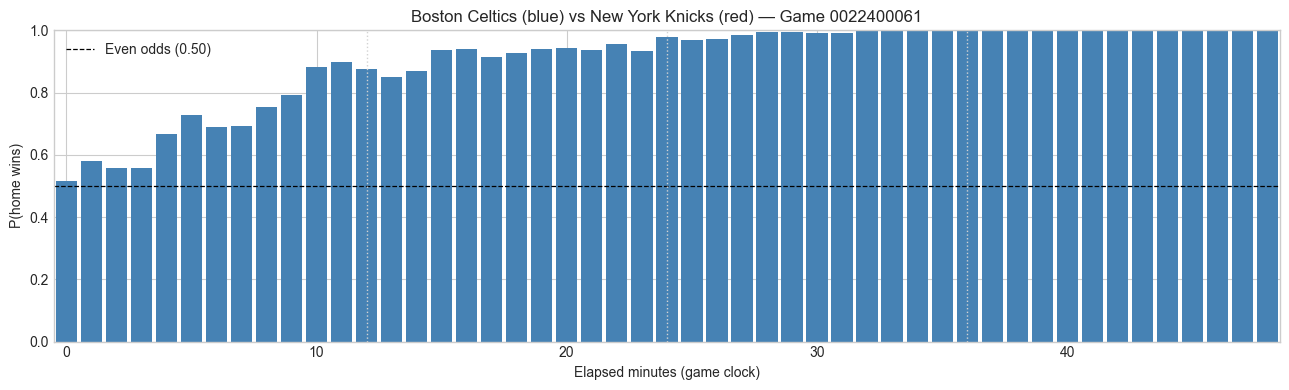

Final margin: +23  →  Boston Celtics won


In [8]:
GAME_ID = games_final.iloc[0]['game_id']  # change this to inspect any game

game = game_minutes[game_minutes['game_id'] == GAME_ID].sort_values('minute_bucket')
game_row = games_final[games_final['game_id'] == GAME_ID].iloc[0]

home = game_row['home_team_name']
away = game_row['away_team_name']
home_won = bool(game_row['home_win'])
final_margin = int(game_row['final_margin'])

# Bars coloured by which team is favoured at that minute
colors = ['steelblue' if p >= 0.5 else 'firebrick' for p in game['win_prob']]

fig, ax = plt.subplots(figsize=(13, 4))
ax.bar(game['minute_bucket'], game['win_prob'], color=colors, width=0.85)
ax.axhline(0.5, color='black', linestyle='--', linewidth=0.9, label='Even odds (0.50)')

for q_end in [12, 24, 36]:
    ax.axvline(q_end, color='lightgray', linestyle=':', linewidth=1)

ax.set_xlim(-0.5, 48.5)
ax.set_ylim(0, 1)
ax.set_xlabel('Elapsed minutes (game clock)')
ax.set_ylabel('P(home wins)')
ax.set_title(f'{home} (blue) vs {away} (red) — Game {GAME_ID}')
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()

outcome_str = f'{home} won' if home_won else f'{away} won'
print(f"Final margin: {final_margin:+d}  →  {outcome_str}")

## 3. Brier scores at quarter boundaries

Rather than evaluating the model at every minute, we pick three specific moments — the start of Q2, Q3, and Q4 (minutes 12, 24, and 36) — and ask: how good are the model's predictions at each of those snapshots?

This is a natural way to measure how much the model improves as the game progresses. By the start of Q4 the model has seen 36 minutes of actual play, so τ is small and the margin has had time to diverge — predictions should be sharper and more accurate than at the start of Q2.

**Brier score:** mean squared error between predicted probability and actual binary outcome. Lower = better. A naive model that always predicts 0.5 scores 0.25.

As a reminder, the Brier score is computed as follows:

$$ \frac{1}{N} \sum_{i = 1}^{N} (p_i - o_i)^2$$

where $N$ is the number of games you have analyzed, $p_i$ is the predicted probability of the home team winning game $i$, and $o_i$ is the observed outcome of the game (a 1 if home wins and 0 if away wins).

**Correct predictions:** cases where the model's favored team ($P > 0.5$ → home, $P < 0.5$ → away) matches the actual winner. This is a rougher metric than Brier score since it ignores how confident the prediction was, but it's intuitive.

In [9]:
def brier_score(predicted_probs: pd.Series, actual_outcomes: pd.Series) -> float:
    """Mean squared error between predicted probabilities and binary outcomes."""
    return float(np.mean((predicted_probs.values - actual_outcomes.values) ** 2))


def evaluate_at_minute(df: pd.DataFrame, minute: int) -> dict:
    """
    Evaluate model predictions at a specific elapsed minute across all games.
    Returns Brier score, correct prediction count, and total games.
    """
    snapshot = df[df['minute_bucket'] == minute].copy()
    bs = brier_score(snapshot['win_prob'], snapshot['home_win'])
    correct = (snapshot['win_prob'].round() == snapshot['home_win']).sum()
    return {
        'minute':  minute,
        'brier':   bs,
        'correct': int(correct),
        'total':   len(snapshot),
    }


# Evaluate at the start of Q2, Q3, Q4
result_q2 = evaluate_at_minute(game_minutes, minute=12)
result_q3 = evaluate_at_minute(game_minutes, minute=24)
result_q4 = evaluate_at_minute(game_minutes, minute=36)

results = [result_q2, result_q3, result_q4]

Checkpoint            Brier score    Correct    Total   Accuracy
--------------------------------------------------------------
Q2 start (min 12)          0.2140        811    1,225     66.2%
Q3 start (min 24)          0.1731        907    1,225     74.0%
Q4 start (min 36)          0.1186      1,002    1,225     81.8%
--------------------------------------------------------------
Naive baseline (0.25)       0.2500


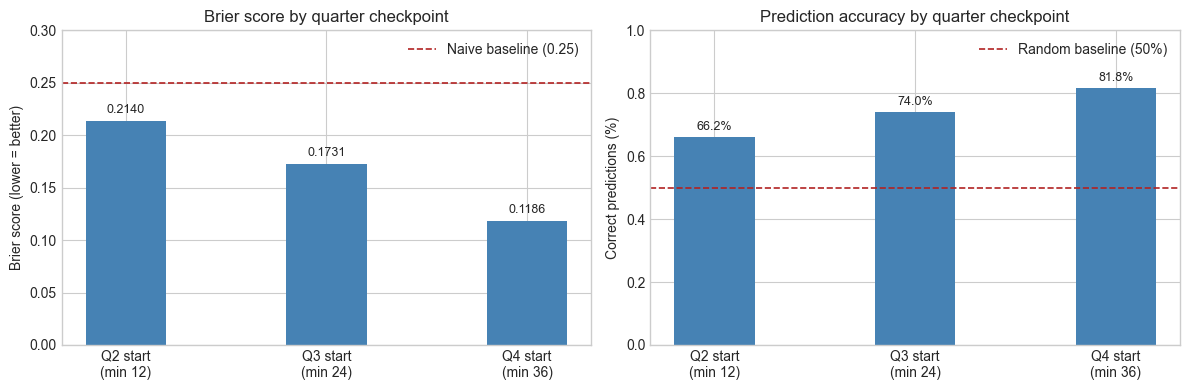

In [10]:
labels = ['Q2 start\n(min 12)', 'Q3 start\n(min 24)', 'Q4 start\n(min 36)']
briers  = [r['brier']   for r in results]
correct = [r['correct'] for r in results]
totals  = [r['total']   for r in results]

# --- Print summary ---
print(f"{'Checkpoint':<20} {'Brier score':>12} {'Correct':>10} {'Total':>8} {'Accuracy':>10}")
print("-" * 62)
for label, r in zip(labels, results):
    label_flat = label.replace('\n', ' ')
    acc = r['correct'] / r['total']
    print(f"{label_flat:<20} {r['brier']:>12.4f} {r['correct']:>10,} {r['total']:>8,} {acc:>9.1%}")
print("-" * 62)
print(f"{'Naive baseline (0.25)':<20}   {'0.2500':>10}")

# --- Bar chart ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Brier scores
ax = axes[0]
bars = ax.bar(labels, briers, color='steelblue', width=0.4)
ax.axhline(0.25, color='firebrick', linestyle='--', linewidth=1.2, label='Naive baseline (0.25)')
ax.bar_label(bars, fmt='%.4f', padding=3, fontsize=9)
ax.set_ylabel('Brier score (lower = better)')
ax.set_title('Brier score by quarter checkpoint')
ax.set_ylim(0, 0.30)
ax.legend()

# Accuracy
ax2 = axes[1]
accuracies = [r['correct'] / r['total'] for r in results]
bars2 = ax2.bar(labels, accuracies, color='steelblue', width=0.4)
ax2.axhline(0.5, color='firebrick', linestyle='--', linewidth=1.2, label='Random baseline (50%)')
ax2.bar_label(bars2, fmt='%.1f%%', padding=3, fontsize=9,
              labels=[f'{a:.1%}' for a in accuracies])
ax2.set_ylabel('Correct predictions (%)')
ax2.set_title('Prediction accuracy by quarter checkpoint')
ax2.set_ylim(0, 1)
ax2.legend()

plt.tight_layout()
plt.show()

## 4. Calibration curve

The Brier score and accuracy tell us the model is discriminating well, but not whether its probabilities are accurate in absolute terms. A model that says 80% when the true probability is 65% would still pick the right winner most of the time, but its probability estimates would be untrustworthy for trading.

The calibration curve answers this directly: we bucket all predictions by their predicted probability (e.g. 50–55%, 55–60%, …) and compute the actual win rate within each bucket. If the model is perfectly calibrated, the points lie on the 45° diagonal — a prediction of 70% should correspond to a 70% actual win rate.

We plot the calibration curve separately for each of the three quarter checkpoints (minutes 12, 24, 36). This lets us see not only whether the model is calibrated, but whether calibration improves as the game progresses and predictions sharpen.

In [11]:
def calibration_curve(df: pd.DataFrame, minute: int, n_bins: int = 10) -> pd.DataFrame:
    """
    Compute calibration data for predictions at a specific minute.
    Buckets win_prob into n_bins equal-width bins, computes actual win rate per bucket.
    Returns a DataFrame with bin midpoint, mean predicted prob, actual win rate, and count.
    """
    snapshot = df[df['minute_bucket'] == minute].copy()
    bin_edges = np.linspace(0, 1, n_bins + 1)
    snapshot['bin'] = pd.cut(snapshot['win_prob'], bins=bin_edges, include_lowest=True)

    cal = (
        snapshot.groupby('bin', observed=True)
        .agg(
            mean_predicted=('win_prob',  'mean'),
            actual_win_rate=('home_win', 'mean'),
            count=('home_win', 'count'),
        )
        .reset_index()
    )
    cal['bin_midpoint'] = [interval.mid for interval in cal['bin']]
    return cal.dropna(subset=['mean_predicted', 'actual_win_rate'])

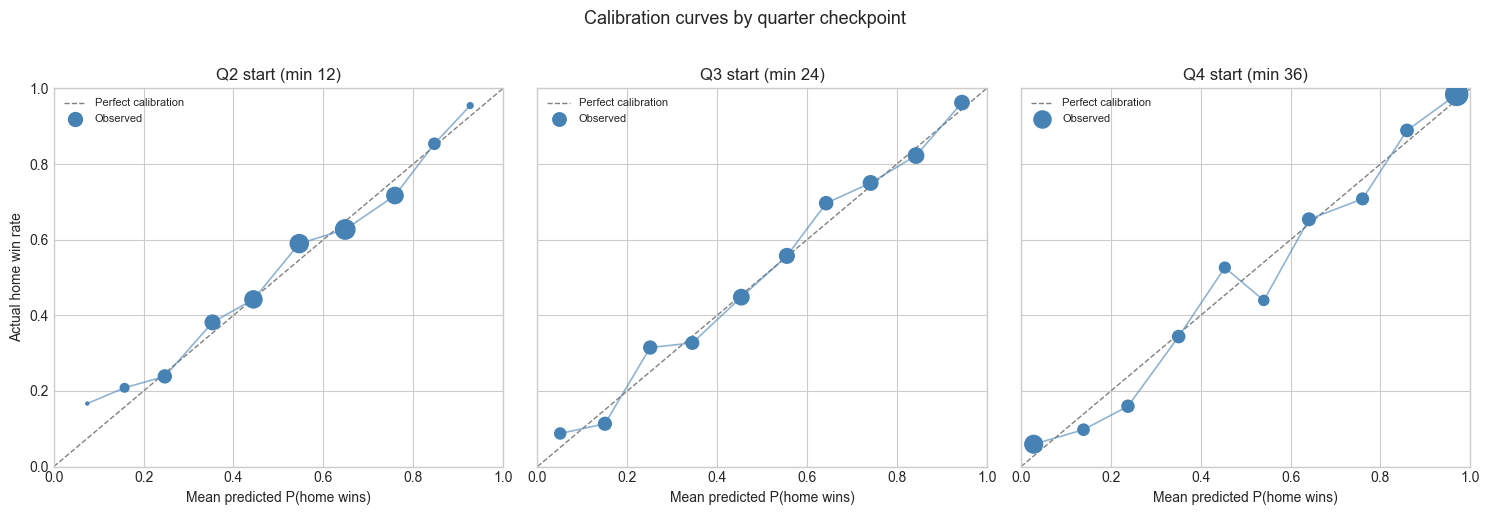

In [12]:
checkpoints = [(12, 'Q2 start (min 12)'), (24, 'Q3 start (min 24)'), (36, 'Q4 start (min 36)')]

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

for ax, (minute, title) in zip(axes, checkpoints):
    cal = calibration_curve(game_minutes, minute=minute)

    # Perfect calibration diagonal
    ax.plot([0, 1], [0, 1], color='gray', linestyle='--', linewidth=1, label='Perfect calibration')

    # Calibration points sized by number of games in each bucket
    scatter = ax.scatter(
        cal['mean_predicted'], cal['actual_win_rate'],
        s=cal['count'] * 0.8, color='steelblue', zorder=3, label='Observed'
    )

    # Connect the dots so the curve shape is clear
    ax.plot(cal['mean_predicted'], cal['actual_win_rate'],
            color='steelblue', linewidth=1.2, alpha=0.6)

    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_xlabel('Mean predicted P(home wins)')
    ax.set_title(title)
    ax.legend(fontsize=8)

axes[0].set_ylabel('Actual home win rate')

plt.suptitle('Calibration curves by quarter checkpoint', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 5. Quarter-specific σ

In sections 3 and 4 we used a single regulation σ = 2.63 for all predictions. But notebook 02 showed that volatility varies meaningfully by quarter — Q4 in particular has lower σ due to strategic fouling and clock stoppages. Using a single average σ overestimates uncertainty in Q4, pulling predictions toward 50% when they should be more extreme.

**Where the values come from:** The per-quarter σ estimates are taken directly from `sigma_by_quarter` in `02_parameter_estimation.ipynb` — the full-quarter values, not the trimmed ones. The trimmed analysis (shaving the last 2 minutes of Q2/Q4) was purely diagnostic, to understand *why* Q4 σ is lower. For the model we want σ to reflect the actual volatility the game produces across the whole quarter, including those final minutes, since that is the regime we are trading in.

**How we apply it — integrated variance:** At any minute m, the remaining game spans multiple quarters each with its own σ. The correct combination under Brownian motion is via integrated variance: total variance accumulates as ∫σ²(t)dt, so the effective σ for the remaining τ minutes is:

$$\sigma_{\text{eff}} = \sqrt{\frac{\sum_{q} \sigma_q^2 \cdot \Delta t_q}{\tau}}$$

where $\Delta t_q$ is the number of remaining minutes in quarter $q$. At minute 36 only Q4 remains so $\sigma_{\text{eff}} = \sigma_{Q4}$. At minute 12 all three remaining quarters contribute equally.

**Benefits:** More accurate late-game predictions — a small lead at minute 36 produces a more extreme probability than the constant-σ model gives, which matches the reality that leads are safer when less time remains and scoring is slower.

**Drawbacks:** Three extra parameters to estimate, each on only ~12 minutes of data per game. Small estimation errors in per-quarter σ propagate into predictions. The model is also slightly harder to explain to a third party.

In [13]:
# Per-quarter σ values — fill these in from sigma_by_quarter output in 02_parameter_estimation.ipynb.
# Run the estimate_sigma_by_quarter cell there and copy the 'sigma' column values here.
SIGMA_BY_QUARTER = {
    1: 2.594980,   # Q1 
    2: 2.559206,   # Q2
    3: 2.586710,   # Q3
    4: 2.473323,   # Q4 
} # NOTE: Initial values put into here were all 2.63, which would have yielded the same results as before.
#         The correct values have now been put in here. These were populated from the results of notebook 2.


def compute_effective_sigma(minute_bucket: np.ndarray) -> np.ndarray:
    """
    Compute σ_eff for each row using integrated variance over remaining quarters.
    σ_eff = sqrt(Σ σ²_q * Δt_q / τ), where Δt_q is remaining minutes in quarter q.
    """
    m = minute_bucket
    r_q1 = np.maximum(0, 12 - m)
    r_q2 = np.maximum(0, 24 - np.maximum(m, 12))
    r_q3 = np.maximum(0, 36 - np.maximum(m, 24))
    r_q4 = np.maximum(0, 48 - np.maximum(m, 36))
    tau   = r_q1 + r_q2 + r_q3 + r_q4

    total_variance = (
        SIGMA_BY_QUARTER[1] ** 2 * r_q1 +
        SIGMA_BY_QUARTER[2] ** 2 * r_q2 +
        SIGMA_BY_QUARTER[3] ** 2 * r_q3 +
        SIGMA_BY_QUARTER[4] ** 2 * r_q4
    )
    return np.sqrt(total_variance / np.maximum(tau, 1e-9))


def compute_win_probabilities_qs(df: pd.DataFrame, mu: float = MU) -> pd.DataFrame:
    """
    Compute P(home wins) using quarter-specific σ via integrated variance.
    The formula simplifies to Φ((x + μτ) / √(Σ σ²_q Δt_q)).
    """
    margin      = df['score_margin'].values
    tau         = df['tau'].values
    m           = df['minute_bucket'].values

    r_q1 = np.maximum(0, 12 - m)
    r_q2 = np.maximum(0, 24 - np.maximum(m, 12))
    r_q3 = np.maximum(0, 36 - np.maximum(m, 24))
    r_q4 = np.maximum(0, 48 - np.maximum(m, 36))

    total_variance = (
        SIGMA_BY_QUARTER[1] ** 2 * r_q1 +
        SIGMA_BY_QUARTER[2] ** 2 * r_q2 +
        SIGMA_BY_QUARTER[3] ** 2 * r_q3 +
        SIGMA_BY_QUARTER[4] ** 2 * r_q4
    )

    formula_prob = norm.cdf((margin + mu * tau) / np.sqrt(np.maximum(total_variance, 1e-9)))

    at_buzzer = np.where(margin > 0, 1.0, np.where(margin < 0, 0.0, 0.5))
    win_prob  = np.where(tau > 0, formula_prob, at_buzzer)

    return pd.DataFrame({
        'game_id':       df['game_id'].values,
        'minute_bucket': m,
        'win_prob_qs':   win_prob,
    })


win_prob_qs_df = compute_win_probabilities_qs(minute_margins)
game_minutes_qs = game_minutes.merge(win_prob_qs_df, on=['game_id', 'minute_bucket'], how='inner')

print(f"Rows: {len(game_minutes_qs):,}")
print(f"win_prob_qs range: {game_minutes_qs['win_prob_qs'].min():.4f} – {game_minutes_qs['win_prob_qs'].max():.4f}")
game_minutes_qs[['game_id', 'minute_bucket', 'score_margin', 'tau', 'home_win', 'win_prob', 'win_prob_qs']].head(10)

Rows: 60,025
win_prob_qs range: 0.0000 – 1.0000


,game_id,minute_bucket,score_margin,tau,home_win,win_prob,win_prob_qs
0,0022400001,0,0,48,0,0.536949,0.538045
1,0022400001,1,0,47,0,0.536563,0.537660
2,0022400001,2,-1,46,0,0.513854,0.514276
3,0022400001,3,-1,45,0,0.513212,0.513619
4,0022400001,4,-3,44,0,0.466861,0.465827
5,0022400001,5,-1,43,0,0.511887,0.512264
6,0022400001,6,-1,42,0,0.511204,0.511564
7,0022400001,7,0,41,0,0.534155,0.535266
8,0022400001,8,-2,40,0,0.485812,0.485343
9,0022400001,9,-2,39,0,0.484777,0.484266


In [14]:
def evaluate_at_minute_qs(df: pd.DataFrame, minute: int) -> dict:
    """evaluate_at_minute but using win_prob_qs column."""
    snapshot = df[df['minute_bucket'] == minute].copy()
    bs      = brier_score(snapshot['win_prob_qs'], snapshot['home_win'])
    correct = (snapshot['win_prob_qs'].round() == snapshot['home_win']).sum()
    return {'minute': minute, 'brier': bs, 'correct': int(correct), 'total': len(snapshot)}


result_q2_qs = evaluate_at_minute_qs(game_minutes_qs, minute=12)
result_q3_qs = evaluate_at_minute_qs(game_minutes_qs, minute=24)
result_q4_qs = evaluate_at_minute_qs(game_minutes_qs, minute=36)
results_qs   = [result_q2_qs, result_q3_qs, result_q4_qs]

Checkpoint            Brier (const σ)  Brier (QS σ)   Δ Brier   Acc (const σ)  Acc (QS σ)
------------------------------------------------------------------------------------------
Q2 start (min 12)              0.2140        0.2142   +0.0002          66.2%       66.2%
Q3 start (min 24)              0.1731        0.1731   +0.0000          74.0%       74.0%
Q4 start (min 36)              0.1186        0.1185   -0.0001          81.8%       81.8%
------------------------------------------------------------------------------------------
Naive baseline                 0.2500


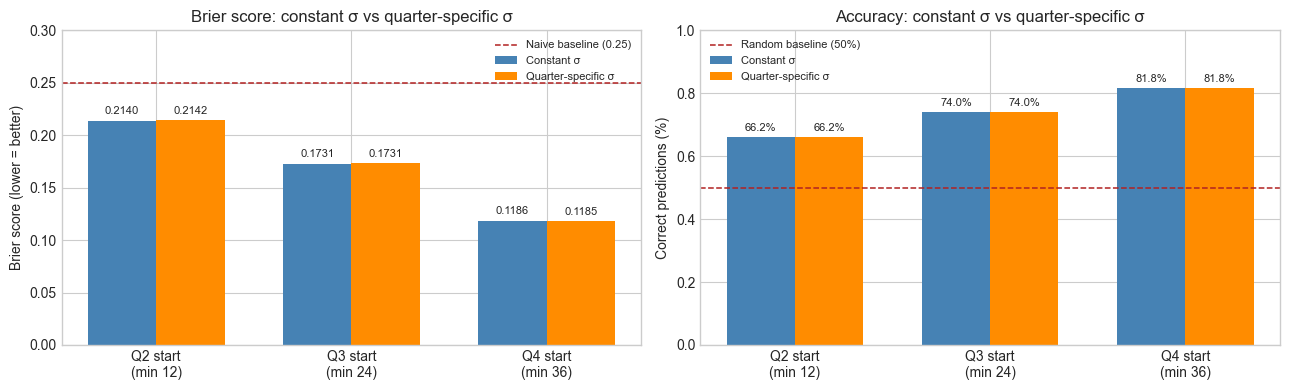

In [15]:
labels = ['Q2 start\n(min 12)', 'Q3 start\n(min 24)', 'Q4 start\n(min 36)']

# --- Print comparison table ---
print(f"{'Checkpoint':<20} {'Brier (const σ)':>16} {'Brier (QS σ)':>13} {'Δ Brier':>9}  {'Acc (const σ)':>14} {'Acc (QS σ)':>11}")
print("-" * 90)
for label, r_const, r_qs in zip(labels, results, results_qs):
    label_flat = label.replace('\n', ' ')
    delta = r_qs['brier'] - r_const['brier']
    acc_c = r_const['correct'] / r_const['total']
    acc_q = r_qs['correct']   / r_qs['total']
    print(f"{label_flat:<20} {r_const['brier']:>16.4f} {r_qs['brier']:>13.4f} {delta:>+9.4f}  {acc_c:>13.1%} {acc_q:>11.1%}")
print("-" * 90)
print(f"{'Naive baseline':<20} {'0.2500':>16}")

# --- Bar charts ---
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
x      = np.arange(3)
width  = 0.35

# Brier scores
ax = axes[0]
bars_c = ax.bar(x - width/2, [r['brier'] for r in results],    width, label='Constant σ', color='steelblue')
bars_q = ax.bar(x + width/2, [r['brier'] for r in results_qs], width, label='Quarter-specific σ', color='darkorange')
ax.axhline(0.25, color='firebrick', linestyle='--', linewidth=1.1, label='Naive baseline (0.25)')
ax.bar_label(bars_c, fmt='%.4f', padding=3, fontsize=8)
ax.bar_label(bars_q, fmt='%.4f', padding=3, fontsize=8)
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel('Brier score (lower = better)')
ax.set_title('Brier score: constant σ vs quarter-specific σ')
ax.set_ylim(0, 0.30)
ax.legend(fontsize=8)

# Accuracy
ax2 = axes[1]
acc_c = [r['correct'] / r['total'] for r in results]
acc_q = [r['correct'] / r['total'] for r in results_qs]
bars_c2 = ax2.bar(x - width/2, acc_c, width, label='Constant σ', color='steelblue')
bars_q2 = ax2.bar(x + width/2, acc_q, width, label='Quarter-specific σ', color='darkorange')
ax2.axhline(0.5, color='firebrick', linestyle='--', linewidth=1.1, label='Random baseline (50%)')
ax2.bar_label(bars_c2, labels=[f'{a:.1%}' for a in acc_c], padding=3, fontsize=8)
ax2.bar_label(bars_q2, labels=[f'{a:.1%}' for a in acc_q], padding=3, fontsize=8)
ax2.set_xticks(x)
ax2.set_xticklabels(labels)
ax2.set_ylabel('Correct predictions (%)')
ax2.set_title('Accuracy: constant σ vs quarter-specific σ')
ax2.set_ylim(0, 1)
ax2.legend(fontsize=8)

plt.tight_layout()
plt.show()

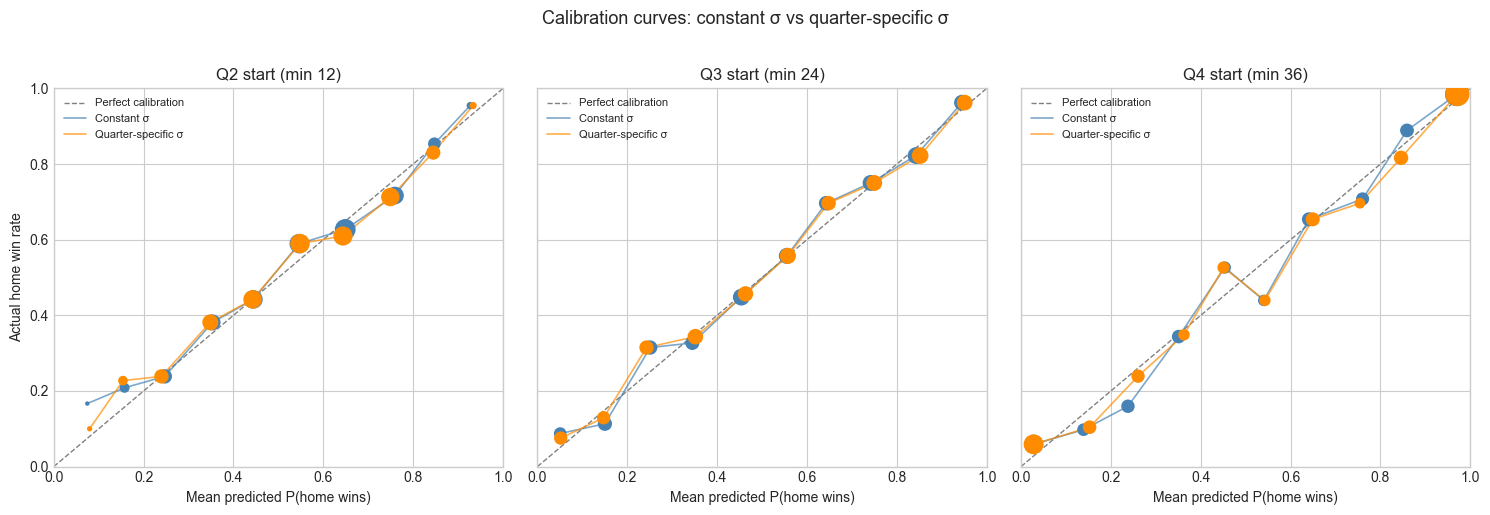

In [16]:
def calibration_curve_qs(df: pd.DataFrame, minute: int, n_bins: int = 10) -> pd.DataFrame:
    """calibration_curve but using win_prob_qs column."""
    snapshot = df[df['minute_bucket'] == minute].copy()
    bin_edges = np.linspace(0, 1, n_bins + 1)
    snapshot['bin'] = pd.cut(snapshot['win_prob_qs'], bins=bin_edges, include_lowest=True)
    cal = (
        snapshot.groupby('bin', observed=True)
        .agg(
            mean_predicted=('win_prob_qs', 'mean'),
            actual_win_rate=('home_win',   'mean'),
            count=('home_win', 'count'),
        )
        .reset_index()
    )
    cal['bin_midpoint'] = [interval.mid for interval in cal['bin']]
    return cal.dropna(subset=['mean_predicted', 'actual_win_rate'])


checkpoints = [(12, 'Q2 start (min 12)'), (24, 'Q3 start (min 24)'), (36, 'Q4 start (min 36)')]

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

for ax, (minute, title) in zip(axes, checkpoints):
    cal_c  = calibration_curve(game_minutes_qs,    minute=minute)  # constant σ
    cal_qs = calibration_curve_qs(game_minutes_qs, minute=minute)  # quarter-specific σ

    ax.plot([0, 1], [0, 1], color='gray', linestyle='--', linewidth=1, label='Perfect calibration')
    ax.plot(cal_c['mean_predicted'],  cal_c['actual_win_rate'],
            color='steelblue', linewidth=1.2, alpha=0.7, label='Constant σ')
    ax.scatter(cal_c['mean_predicted'], cal_c['actual_win_rate'],
               s=cal_c['count'] * 0.8, color='steelblue', zorder=3)
    ax.plot(cal_qs['mean_predicted'], cal_qs['actual_win_rate'],
            color='darkorange', linewidth=1.2, alpha=0.7, label='Quarter-specific σ')
    ax.scatter(cal_qs['mean_predicted'], cal_qs['actual_win_rate'],
               s=cal_qs['count'] * 0.8, color='darkorange', zorder=3)

    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_xlabel('Mean predicted P(home wins)')
    ax.set_title(title)
    ax.legend(fontsize=8)

axes[0].set_ylabel('Actual home win rate')
plt.suptitle('Calibration curves: constant σ vs quarter-specific σ', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## Analysis of these results

These results seem to indicate that using quarter-specific sigma values does not provide a meaningful difference in performance; to be fair, the QS sigma values are quite close to the overall estimated sigma value, except for in Q4, where it did seem to see an improvement, if minor. It could be useful to use the QS sigma value specifically for the fourth quarter, but either way, the differences seemingly won't be significant.